## Showcases TrustCVValidator



- **TrustCVValidator** is just a callable object; you can loop over random seeds and configurations exactly like we did here.
- You can rely on:
  - consistent metric names (`mean_scores["accuracy"]`)
  - built-in **confidence intervals** (`confidence_intervals["accuracy"]`)
  - optional **leakage** and **balance** checks per run, if you want to inspect them.
- The comparison between `stratify=True` vs `stratify=None` makes it clear that **stratified holdout** is more stable on imbalanced datasets — which is exactly the kind of best-practice TrustCV is trying to encourage.

-----

# TrustCVValidator – HoldOut across random seeds (stratified vs non-stratified)

Goal:

- Use `TrustCVValidator` with `method="HoldOut"` on the breast cancer dataset.
- Sweep different `random_state` values.
- Compare accuracy variance when:
  - `stratify=True` (or `stratify=y` in your implementation)
  - `stratify=None` (no stratification)
- Summarise results with:
  - a **boxplot** of accuracies across seeds
  - a **table** of mean / std / min / max

This demonstrates how **TrustCVValidator** behaves as a small evaluation engine
that you can call in a loop with different configurations.


------


### 1 – Imports & data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from trustcv import TrustCVValidator  # adjust import if you keep it elsewhere

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette(['#870052', '#FF876F', '#4F0433', '#EDF4F4'])

# Load data
X, y = load_breast_cancer(return_X_y=True)
print("X shape:", X.shape, "| y shape:", y.shape)

# Baseline model (any sklearn estimator with fit/predict will work)
base_model = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)
base_model


X shape: (569, 30) | y shape: (569,)


,steps,"[('standardscaler', ...), ('randomforestclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2


## Cell 3 – Helper: run one HoldOut experiment with TrustCVValidator

> ⚠️ Note: depending on how you implemented it, your `method` string might be `"HoldOut"` or `"holdout"`.
>  Replace `"HoldOut"` below with whatever your `TrustCVValidator` expects.

In [13]:
def run_holdout_once(
    model,
    X,
    y,
    random_state: int,
    stratify_flag,
):
    """
    Run TrustCVValidator once for a given random_state and stratify flag.

    Returns:
        accuracy_mean, (ci_low, ci_high), full ValidationResult
    """
    validator = TrustCVValidator(
        method="HoldOut",          # or "holdout" in your implementation
        test_size=0.2,
        stratify=stratify_flag,    # True / None (or y / None if you coded it that way)
        random_state=random_state,
        check_leakage=True,
        check_balance=True,
        metrics=["accuracy"],
        return_confidence_intervals=True,
        ci_method="t-interval",    # or "bootstrap"
        ci_level=0.95,
    )

    result = validator.validate(model=model, X=X, y=y)

    # For HoldOut there is usually only one split, but mean_scores is robust.
    acc_mean = result.mean_scores["accuracy"]
    ci_low, ci_high = result.confidence_intervals["accuracy"]

    return acc_mean, (ci_low, ci_high), result


You can quickly test one run:

In [14]:
acc, ci, res = run_holdout_once(
    model=base_model,
    X=X,
    y=y,
    random_state=42,
    stratify_flag=True,   # stratified holdout
)
print(res.summary())


=== Trustworthy Cross-Validation Results ===

Performance Metrics (mean +/- std) (method: t-interval):
  accuracy: 0.956 +/- 0.000 [95% CI: n/a]

Data Integrity Checks:
  Leakage Check: PASSED
  Class Balance: PASSED



### 3 – Sweep random_state for stratified vs non-stratified

We’ll sweep several random seeds and store the resulting accuracies in a DataFrame.

In [15]:
seeds = list(range(10, 60, 5))  # e.g. 10, 15, 20, ..., 55  (adjust as you like)

records = []

for seed in seeds:
    # --- stratified (stratify=True) ---
    acc_s, (ciL_s, ciU_s), _ = run_holdout_once(
        model=base_model,
        X=X,
        y=y,
        random_state=seed,
        stratify_flag=True,   # or stratify=y if that is your API
    )
    records.append({
        "random_state": seed,
        "stratify": "True",
        "accuracy": acc_s,
        "ci_low": ciL_s,
        "ci_high": ciU_s,
    })

    # --- non-stratified (stratify=None) ---
    acc_ns, (ciL_ns, ciU_ns), _ = run_holdout_once(
        model=base_model,
        X=X,
        y=y,
        random_state=seed,
        stratify_flag=None,
    )
    records.append({
        "random_state": seed,
        "stratify": "None",
        "accuracy": acc_ns,
        "ci_low": ciL_ns,
        "ci_high": ciU_ns,
    })

results_df = pd.DataFrame(records)
results_df.head()


,random_state,stratify,accuracy,ci_low,ci_high
0,10,True,0.947368,NaN,NaN
1,10,None,0.982301,NaN,NaN
2,15,True,0.973684,NaN,NaN
3,15,None,0.929204,NaN,NaN
4,20,True,0.964912,NaN,NaN


### 4 – Summary table (mean / std / min / max)

In [16]:
summary = (
    results_df
    .groupby("stratify")["accuracy"]
    .agg(["mean", "std", "min", "max"])
    .rename(columns={
        "mean": "acc_mean",
        "std": "acc_std",
        "min": "acc_min",
        "max": "acc_max",
    })
)

summary


,acc_mean,acc_std,acc_min,acc_max
stratify,,,,
None,0.961947,0.020029,0.929204,0.991150
True,0.964035,0.017762,0.938596,0.991228


You can also compute a simple range (max – min) as an intuitive measure of variability:

In [18]:
summary["acc_range"] = summary["acc_max"] - summary["acc_min"]
summary


,acc_mean,acc_std,acc_min,acc_max,acc_range
stratify,,,,,
None,0.961947,0.020029,0.929204,0.991150,0.061947
True,0.964035,0.017762,0.938596,0.991228,0.052632


This table directly answers:

- How much **variance in accuracy** do we see across random seeds?
- Does **stratified holdout** show less variation than non-stratified?

------

## Cell 5 – Plot: accuracy vs random_state (line/scatter)

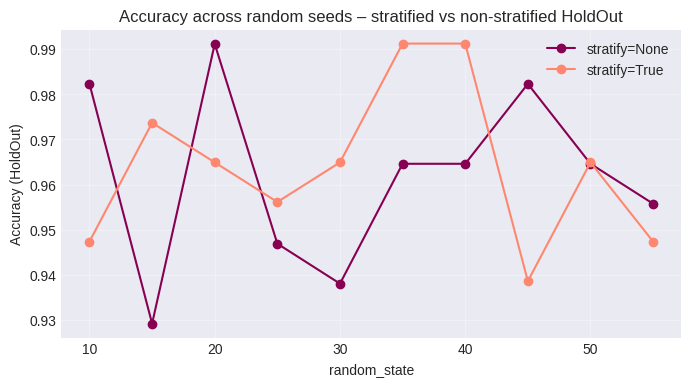

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))

for label, df_sub in results_df.groupby("stratify"):
    ax.plot(
        df_sub["random_state"],
        df_sub["accuracy"],
        marker="o",
        linestyle="-",
        label=f"stratify={label}",
    )

ax.set_xlabel("random_state")
ax.set_ylabel("Accuracy (HoldOut)")
ax.set_title("Accuracy across random seeds – stratified vs non-stratified HoldOut")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


This visualises **how sensitive** the holdout accuracy is to the random split.

------

## Cell 7 – Plot: boxplot of accuracy distributions

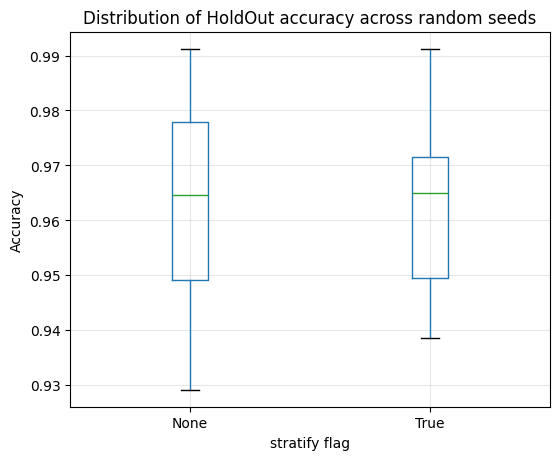

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))

results_df.boxplot(
    column="accuracy",
    by="stratify",
    ax=ax,
)

ax.set_xlabel("stratify flag")
ax.set_ylabel("Accuracy")
ax.set_title("Distribution of HoldOut accuracy across random seeds")
plt.suptitle("")  # remove pandas’ default title
plt.grid(alpha=0.3)
plt.show()


This plot makes it easy to compare:

- central tendency (median)
- spread (IQR, whiskers)

between `stratify=True` and `stratify=None`.